# Previsão de Inadimplência em Cartão de Crédito

Projeto final - Engenharia de Aprendizado de Máquina (Pós UniCEUB)

**Dataset:** Default of Credit Card Clients (UCI, id=350) · **Trilha A** - Classificação

**Metas mínimas:** AUC-ROC ≥ 0,75 · F1 ≥ 0,65 · Recall ≥ 0,60

## Parte 1 - Setup e carregamento dos dados

In [1]:
!pip install ucimlrepo shap faker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
dataset = fetch_ucirepo(id=350)

X = dataset.data.features
y = dataset.data.targets

X.shape, y.shape

((30000, 23), (30000, 1))

In [4]:
# colunas X1, X2... -> renomeadas com os nomes dos metadados
rename_map = dataset.variables.set_index("name")["description"].to_dict()
X = X.rename(columns=rename_map)
y = y.rename(columns=rename_map)

X.columns.tolist()

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [5]:
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [7]:
dataset.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,None,None,no
1,X1,Feature,Integer,None,LIMIT_BAL,None,no
2,X2,Feature,Integer,Sex,SEX,None,no
3,X3,Feature,Integer,Education Level,EDUCATION,None,no
4,X4,Feature,Integer,Marital Status,MARRIAGE,None,no
5,X5,Feature,Integer,Age,AGE,None,no
6,X6,Feature,Integer,None,PAY_0,None,no
7,X7,Feature,Integer,None,PAY_2,None,no
8,X8,Feature,Integer,None,PAY_3,None,no
9,X9,Feature,Integer,None,PAY_4,None,no


## Parte 2 - Análise Exploratória (EDA)

In [8]:
target_col = y.columns[0]
df = pd.concat([X, y], axis=1)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


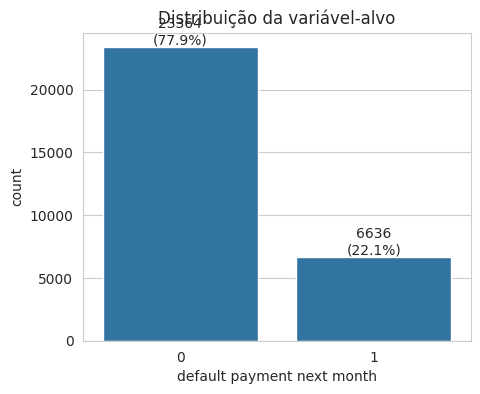

In [11]:
contagem = df[target_col].value_counts()
percentual = df[target_col].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=df[target_col], ax=ax)
for i, v in enumerate(contagem):
    ax.text(i, v, f"{v}\n({percentual.iloc[i]:.1f}%)", ha="center", va="bottom")
ax.set_title("Distribuição da variável-alvo")
plt.show()

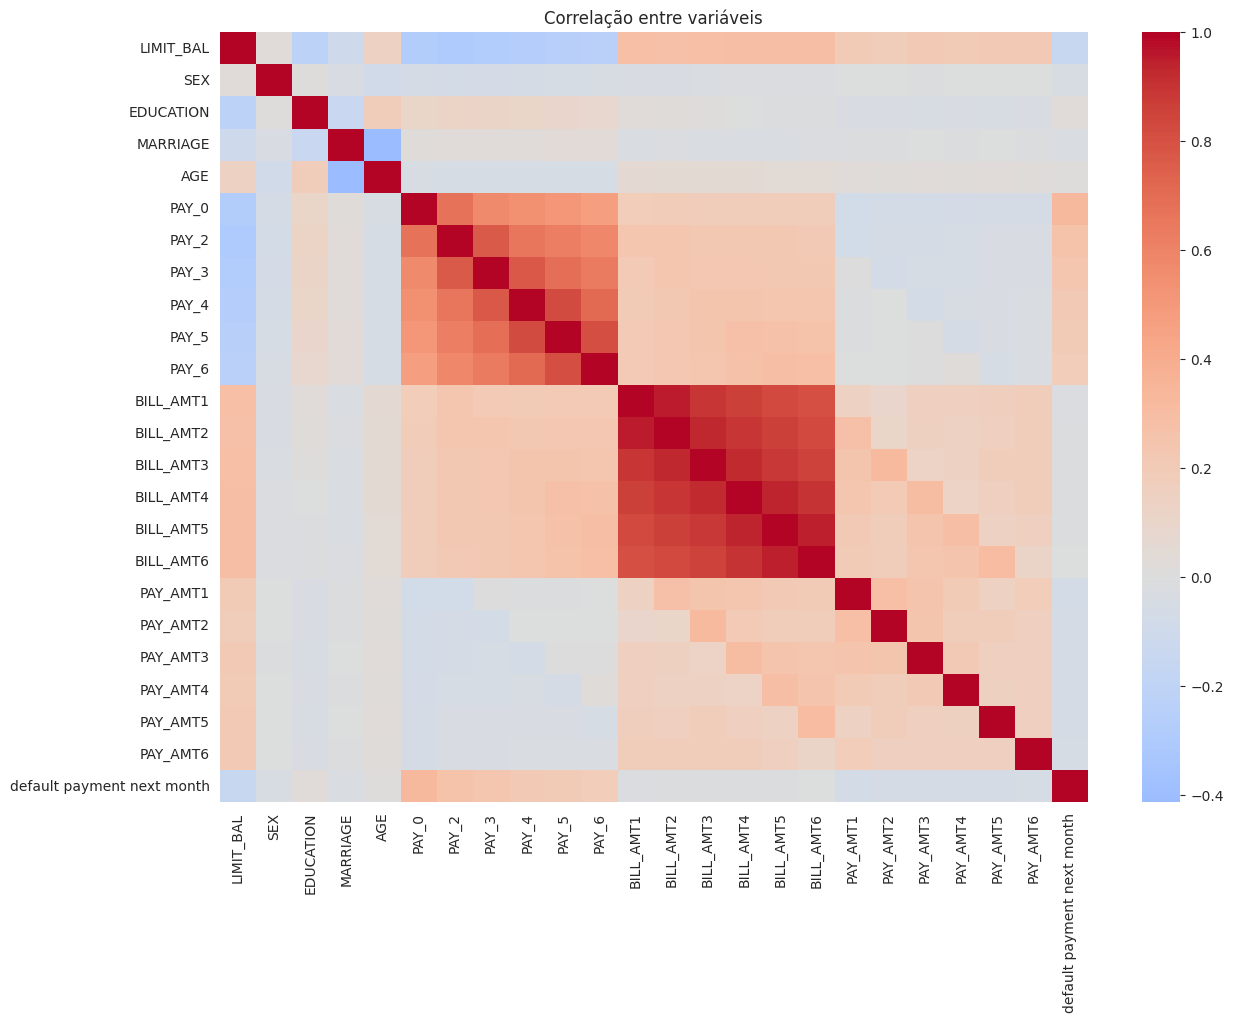

,default payment next month
default payment next month,1.000000
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
EDUCATION,0.028006
AGE,0.013890
BILL_AMT6,-0.005372


In [12]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlação entre variáveis")
plt.show()

corr[target_col].sort_values(ascending=False)

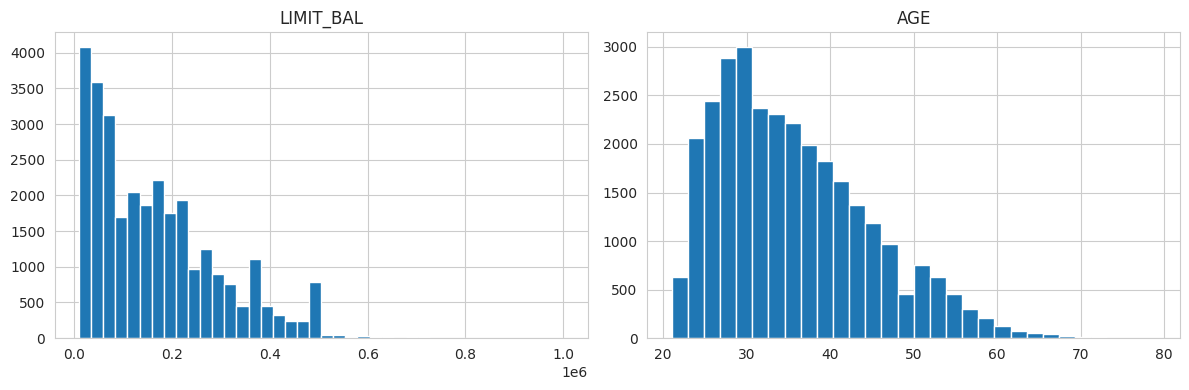

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["LIMIT_BAL"].hist(bins=40, ax=axes[0])
axes[0].set_title("LIMIT_BAL")
df["AGE"].hist(bins=30, ax=axes[1])
axes[1].set_title("AGE")
plt.tight_layout()
plt.show()

In [14]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"--- {col} ---")
    print(df.groupby(col)[target_col].mean().sort_values(ascending=False))
    print()

--- SEX ---
SEX
1    0.241672
2    0.207763
Name: default payment next month, dtype: float64

--- EDUCATION ---
EDUCATION
3    0.251576
2    0.237349
1    0.192348
6    0.156863
5    0.064286
4    0.056911
0    0.000000
Name: default payment next month, dtype: float64

--- MARRIAGE ---
MARRIAGE
3    0.260062
1    0.234717
2    0.209283
0    0.092593
Name: default payment next month, dtype: float64



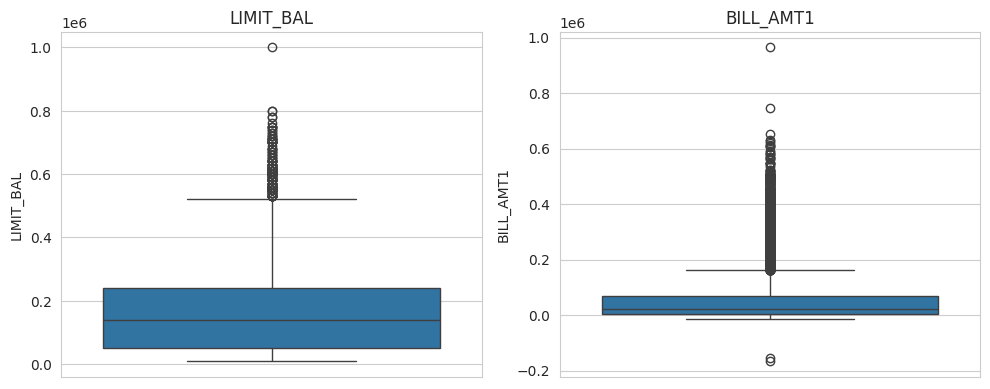

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df["LIMIT_BAL"], ax=axes[0])
axes[0].set_title("LIMIT_BAL")
sns.boxplot(y=df["BILL_AMT1"], ax=axes[1])
axes[1].set_title("BILL_AMT1")
plt.tight_layout()
plt.show()

## Parte 3 - Limpeza e Engenharia de Atributos

In [16]:
df.duplicated().sum()

np.int64(35)

In [17]:
df["EDUCATION"].value_counts()

,count
EDUCATION,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


In [18]:
df["MARRIAGE"].value_counts()

,count
MARRIAGE,
2,15964
1,13659
3,323
0,54


Categorias fora do dicionário oficial (EDUCATION: 0, 5, 6 / MARRIAGE: 0) → agrupando em "outros".

In [19]:
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

In [20]:
X = df.drop(columns=[target_col])
y = df[target_col]

Codificação das variáveis categóricas.

In [21]:
X["SEX"] = X["SEX"].map({1: 1, 2: 0})  # 1 = masculino, 0 = feminino

X = pd.get_dummies(X, columns=["EDUCATION", "MARRIAGE"], drop_first=True)
X.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,0,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,True,False,False,False,False
1,120000,0,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True,False,False,True,False
2,90000,0,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,True,False,False,True,False
3,50000,0,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,True,False,False,False,False
4,50000,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,True,False,False,False,False


Features novas - utilização de crédito e histórico de atraso.

In [22]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

X["utilizacao_credito"] = X["BILL_AMT1"] / (X["LIMIT_BAL"] + 1)
X["media_atraso"] = X[pay_cols].mean(axis=1)
X["meses_em_atraso"] = (X[pay_cols] > 0).sum(axis=1)
X["proporcao_pagamento"] = X[pay_amt_cols].sum(axis=1) / (X[bill_cols].sum(axis=1) + 1)

X.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,utilizacao_credito,media_atraso,meses_em_atraso,proporcao_pagamento
0,20000,0,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,True,False,False,False,False,0.195640,-0.333333,2,0.089422
1,120000,0,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,True,False,False,True,False,0.022350,0.500000,2,0.292774
2,90000,0,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,True,False,False,True,False,0.324874,0.000000,0,0.108387
3,50000,0,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,True,False,False,False,False,0.939781,0.000000,0,0.036259
4,50000,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,True,False,False,False,False,0.172337,-0.333333,0,0.540049


Normalização (StandardScaler) fica pra depois do split treino/teste, pra não vazar informação das outras partições.

## Parte 4 - Separação treino / validação / teste

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

X_train.shape, X_val.shape, X_test.shape

((21000, 30), (4500, 30), (4500, 30))

In [24]:
y_train.mean(), y_val.mean(), y_test.mean()

(np.float64(0.2211904761904762),
 np.float64(0.22111111111111112),
 np.float64(0.22133333333333333))

Normalização das variáveis contínuas - ajustada só no treino.

In [25]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = [c for c in X_train.columns
                 if c != "SEX" and not c.startswith(("EDUCATION_", "MARRIAGE_"))]

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,utilizacao_credito,media_atraso,meses_em_atraso,proporcao_pagamento
11018,-0.057791,0,-0.373240,0.013521,0.111565,0.138827,0.189478,0.240862,0.253727,1.424699,1.505293,1.577598,1.706096,1.908050,1.964345,0.021047,0.004207,0.019302,0.072697,0.077888,0.015063,True,False,False,True,False,1.348006,0.186672,-0.539219,-0.015716
1710,-0.520169,0,-0.590997,0.013521,0.111565,0.138827,0.189478,2.020319,0.253727,-0.309799,-0.228184,-0.068394,0.127656,0.168131,0.230897,-0.039837,0.197427,0.263529,-0.315434,-0.130219,-0.186865,False,False,False,True,False,-0.340502,0.527195,0.103328,-0.015659
4618,-0.674295,1,-0.699875,0.013521,0.111565,0.138827,0.189478,0.240862,0.253727,0.305950,0.367929,0.251634,0.033224,0.031230,0.066603,-0.143340,-0.164860,-0.205164,-0.211933,-0.212433,-0.205902,False,False,False,True,False,1.215975,0.186672,-0.539219,-0.015717
5482,-1.136673,0,-0.917632,0.013521,0.111565,-0.698439,-0.671226,-1.538595,-1.492102,-0.596318,-0.660204,-0.672293,-0.672297,-0.660998,-0.652166,-0.283009,-0.247945,-0.291531,-0.315434,-0.318004,-0.296554,True,False,False,False,False,-0.144127,-0.834899,-0.539219,-0.015615
26187,-0.905484,0,-0.590997,-1.766735,-1.555358,-1.535704,-1.531931,-1.538595,-1.492102,-0.695269,-0.661469,-0.683643,-0.672297,-0.660998,-0.652166,-0.218228,-0.285623,-0.291531,-0.315434,-0.318004,-0.296554,False,False,False,True,False,-1.033272,-1.856470,-0.539219,-0.015009


## Parte 5 - Treinar e comparar modelos

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, accuracy_score

Treinando os 4 modelos da trilha com hiperparâmetros padrão, comparando na validação.

In [27]:
models = {
    "Regressão Logística": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
}

resultados = []

for nome, modelo in models.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_val)

    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_val)[:, 1]
    else:
        y_score = modelo.decision_function(X_val)

    resultados.append({
        "Modelo": nome,
        "AUC-ROC": roc_auc_score(y_val, y_score),
        "F1": f1_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Accuracy": accuracy_score(y_val, y_pred),
    })

pd.DataFrame(resultados).sort_values("AUC-ROC", ascending=False)

,Modelo,AUC-ROC,F1,Recall,Precision,Accuracy
2,Random Forest,0.758124,0.462821,0.362814,0.638938,0.813778
0,Regressão Logística,0.747814,0.396613,0.282412,0.665877,0.810000
3,SVM,0.724082,0.444003,0.336683,0.651751,0.813556
1,Árvore de Decisão,0.590853,0.364087,0.368844,0.359452,0.715111


## Parte 6 - Ajuste de hiperparâmetros e avaliação

Testando `class_weight="balanced"` nos 4 modelos.

In [29]:
models_balanced = {
    "Regressão Logística": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced"),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "SVM": SVC(random_state=RANDOM_STATE, class_weight="balanced"),
}

resultados_balanced = []

for nome, modelo in models_balanced.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_val)

    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_val)[:, 1]
    else:
        y_score = modelo.decision_function(X_val)

    resultados_balanced.append({
        "Modelo": nome,
        "AUC-ROC": roc_auc_score(y_val, y_score),
        "F1": f1_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Accuracy": accuracy_score(y_val, y_pred),
    })

pd.DataFrame(resultados_balanced).sort_values("AUC-ROC", ascending=False)

,Modelo,AUC-ROC,F1,Recall,Precision,Accuracy
2,Random Forest,0.755207,0.432468,0.326633,0.639764,0.810444
3,SVM,0.752352,0.513680,0.584925,0.457907,0.755111
0,Regressão Logística,0.752163,0.516129,0.562814,0.476596,0.766667
1,Árvore de Decisão,0.594694,0.367804,0.362814,0.372934,0.724222


Random Forest - Tuning de hiperparâmetros.

In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 6, 10, 14],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
rf_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': 'log2',
 'max_depth': 10}

In [31]:
y_pred = rf_best.predict(X_val)
y_score = rf_best.predict_proba(X_val)[:, 1]

{
    "AUC-ROC": roc_auc_score(y_val, y_score),
    "F1": f1_score(y_val, y_pred),
    "Recall": recall_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred),
}

{'AUC-ROC': np.float64(0.7776802701094633),
 'F1': 0.538821328344247,
 'Recall': 0.578894472361809,
 'Precision': 0.5039370078740157}

Ajuste do threshold de decisão - buscando Recall ≥ 0,60 maximizando o F1.

In [32]:
from sklearn.metrics import precision_recall_curve

def melhor_threshold(y_true, y_score, recall_min=0.60):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    validos = recalls[:-1] >= recall_min
    if not validos.any():
        return None
    candidatos = np.where(validos, f1s[:-1], -1)
    idx = candidatos.argmax()
    return thresholds[idx], precisions[idx], recalls[idx], f1s[idx]

melhor_threshold(y_val, y_score)

(np.float64(0.471601560077827),
 np.float64(0.4789515488482923),
 np.float64(0.6060301507537689),
 np.float64(0.5350488016364066))

In [33]:
threshold, prec, rec, f1 = melhor_threshold(y_val, y_score)
y_pred_ajustado = (y_score >= threshold).astype(int)

{
    "threshold": threshold,
    "AUC-ROC": roc_auc_score(y_val, y_score),
    "F1": f1_score(y_val, y_pred_ajustado),
    "Recall": recall_score(y_val, y_pred_ajustado),
    "Precision": precision_score(y_val, y_pred_ajustado),
}

{'threshold': np.float64(0.471601560077827),
 'AUC-ROC': np.float64(0.7776802701094633),
 'F1': 0.5350488021295474,
 'Recall': 0.6060301507537689,
 'Precision': 0.4789515488482923}

Gradient Boosting (teste extra).

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb.fit(X_train, y_train)

y_score_gb = gb.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score_gb)

np.float64(0.7819234546484205)

In [35]:
threshold_gb, prec_gb, rec_gb, f1_gb = melhor_threshold(y_val, y_score_gb)
y_pred_gb_ajustado = (y_score_gb >= threshold_gb).astype(int)

{
    "threshold": threshold_gb,
    "AUC-ROC": roc_auc_score(y_val, y_score_gb),
    "F1": f1_score(y_val, y_pred_gb_ajustado),
    "Recall": recall_score(y_val, y_pred_gb_ajustado),
    "Precision": precision_score(y_val, y_pred_gb_ajustado),
}

{'threshold': np.float64(0.2324896834408316),
 'AUC-ROC': np.float64(0.7819234546484205),
 'F1': 0.5434494927216585,
 'Recall': 0.6190954773869347,
 'Precision': 0.48427672955974843}

SMOTE (oversampling) + XGBoost.

In [36]:
!pip install imbalanced-learn xgboost -q
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

y_train_smote.value_counts()

,count
default payment next month,
0,16355
1,16355


In [37]:
gb_smote = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_smote.fit(X_train_smote, y_train_smote)

y_score_gb_smote = gb_smote.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score_gb_smote)

np.float64(0.7718148517193673)

In [38]:
threshold_s, prec_s, rec_s, f1_s = melhor_threshold(y_val, y_score_gb_smote)
y_pred_smote_ajustado = (y_score_gb_smote >= threshold_s).astype(int)

{
    "threshold": threshold_s,
    "AUC-ROC": roc_auc_score(y_val, y_score_gb_smote),
    "F1": f1_score(y_val, y_pred_smote_ajustado),
    "Recall": recall_score(y_val, y_pred_smote_ajustado),
    "Precision": precision_score(y_val, y_pred_smote_ajustado),
}

{'threshold': np.float64(0.44546665191075396),
 'AUC-ROC': np.float64(0.7718148517193673),
 'F1': 0.5298013245033113,
 'Recall': 0.6030150753768844,
 'Precision': 0.47244094488188976}

In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
xgb.fit(X_train, y_train)

y_score_xgb = xgb.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_score_xgb)

np.float64(0.7561687180553266)

In [40]:
threshold_x, prec_x, rec_x, f1_x = melhor_threshold(y_val, y_score_xgb)
y_pred_xgb_ajustado = (y_score_xgb >= threshold_x).astype(int)

{
    "threshold": threshold_x,
    "AUC-ROC": roc_auc_score(y_val, y_score_xgb),
    "F1": f1_score(y_val, y_pred_xgb_ajustado),
    "Recall": recall_score(y_val, y_pred_xgb_ajustado),
    "Precision": precision_score(y_val, y_pred_xgb_ajustado),
}

{'threshold': np.float32(0.22810972),
 'AUC-ROC': np.float64(0.7561687180553266),
 'F1': 0.5071010860484545,
 'Recall': 0.6100502512562814,
 'Precision': 0.43388134381701216}

### Decisão final do modelo

Testei o class_weight balanceado, tuning de hiperparâmetros, threshold ajustado, features novas, SMOTE e XGBoost. O Gradient Boosting (com as features novas, sem SMOTE) teve o melhor equilíbrio entre as 3 métricas. Usarei ele daqui pra frente.

AUC-ROC ≥ 0,75 ✅ · Recall ≥ 0,60 ✅ · F1 ficou em ~0,54 (meta era 0,65, não bateu).

In [41]:
modelo_final = gb
threshold_final = threshold_gb

y_score_final = modelo_final.predict_proba(X_val)[:, 1]
y_pred_final = (y_score_final >= threshold_final).astype(int)

{
    "threshold": threshold_final,
    "AUC-ROC": roc_auc_score(y_val, y_score_final),
    "F1": f1_score(y_val, y_pred_final),
    "Recall": recall_score(y_val, y_pred_final),
    "Precision": precision_score(y_val, y_pred_final),
}

{'threshold': np.float64(0.2324896834408316),
 'AUC-ROC': np.float64(0.7819234546484205),
 'F1': 0.5434494927216585,
 'Recall': 0.6190954773869347,
 'Precision': 0.48427672955974843}

## Parte 7 - Explicabilidade (SHAP) e demonstração

In [42]:
import shap

explainer = shap.TreeExplainer(modelo_final)
X_sample = X_val.sample(500, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)

np.array(shap_values).shape

(500, 30)

/tmp/ipykernel_2050/3161756248.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar")


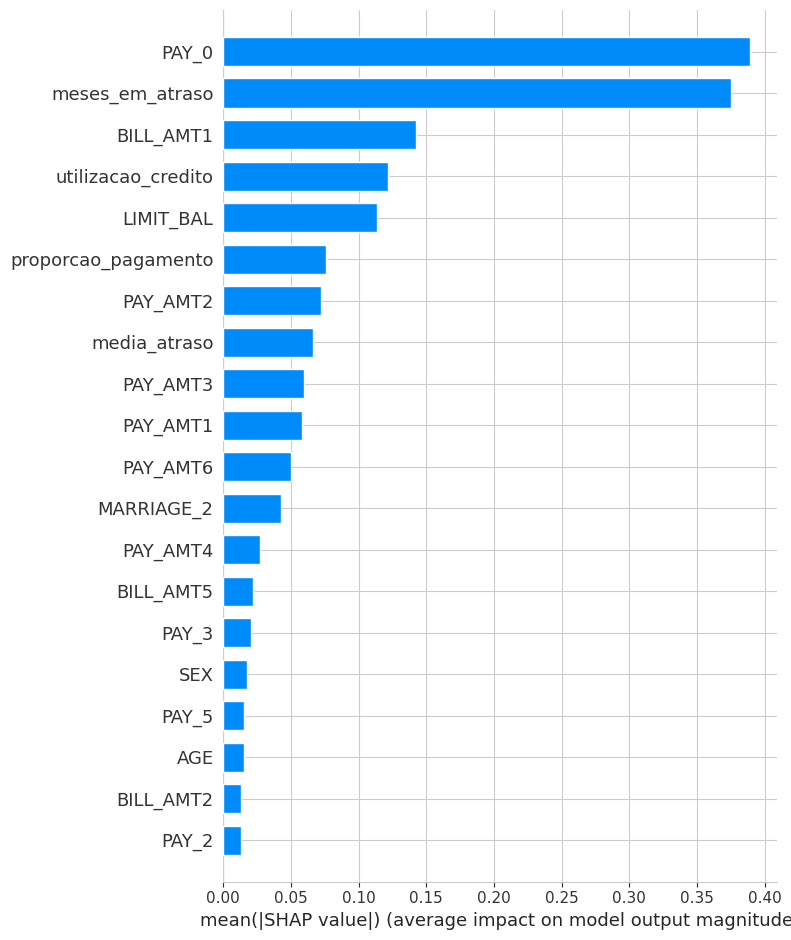

In [43]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

/tmp/ipykernel_2050/3891084168.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


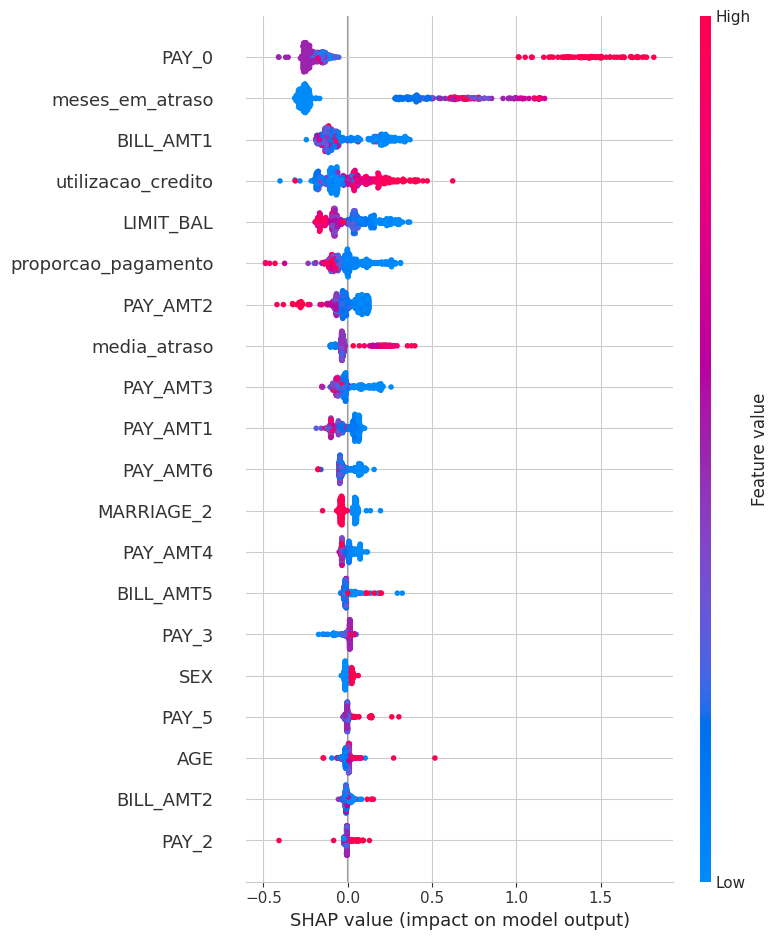

In [44]:
shap.summary_plot(shap_values, X_sample)

Explicação de uma previsão individual.

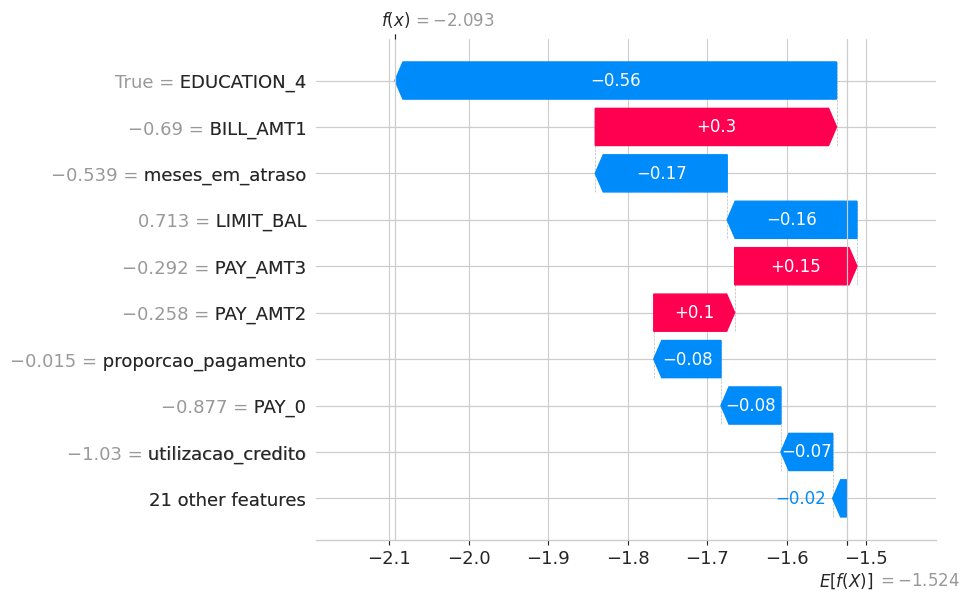

In [45]:
idx = 0
base_value = explainer.expected_value
if hasattr(base_value, "__len__"):
    base_value = base_value[0]

explicacao = shap.Explanation(
    values=shap_values[idx],
    base_values=base_value,
    data=X_sample.iloc[idx],
    feature_names=X_sample.columns.tolist()
)
shap.plots.waterfall(explicacao)

Demonstração de previsão sobre clientes sintéticos (Faker).

In [46]:
from faker import Faker
fake = Faker()
Faker.seed(RANDOM_STATE)

def gerar_cliente_sintetico():
    return {
        "LIMIT_BAL": fake.pyfloat(min_value=10000, max_value=500000, right_digits=2),
        "SEX": fake.random_int(min=1, max=2),
        "EDUCATION": fake.random_int(min=1, max=4),
        "MARRIAGE": fake.random_int(min=1, max=3),
        "AGE": fake.random_int(min=21, max=70),
        "PAY_0": fake.random_int(min=-2, max=8),
        "PAY_2": fake.random_int(min=-2, max=8),
        "PAY_3": fake.random_int(min=-2, max=8),
        "PAY_4": fake.random_int(min=-2, max=8),
        "PAY_5": fake.random_int(min=-2, max=8),
        "PAY_6": fake.random_int(min=-2, max=8),
        "BILL_AMT1": fake.pyfloat(min_value=0, max_value=100000, right_digits=2),
        "BILL_AMT2": fake.pyfloat(min_value=0, max_value=100000, right_digits=2),
        "BILL_AMT3": fake.pyfloat(min_value=0, max_value=100000, right_digits=2),
        "BILL_AMT4": fake.pyfloat(min_value=0, max_value=100000, right_digits=2),
        "BILL_AMT5": fake.pyfloat(min_value=0, max_value=100000, right_digits=2),
        "BILL_AMT6": fake.pyfloat(min_value=0, max_value=100000, right_digits=2),
        "PAY_AMT1": fake.pyfloat(min_value=0, max_value=20000, right_digits=2),
        "PAY_AMT2": fake.pyfloat(min_value=0, max_value=20000, right_digits=2),
        "PAY_AMT3": fake.pyfloat(min_value=0, max_value=20000, right_digits=2),
        "PAY_AMT4": fake.pyfloat(min_value=0, max_value=20000, right_digits=2),
        "PAY_AMT5": fake.pyfloat(min_value=0, max_value=20000, right_digits=2),
        "PAY_AMT6": fake.pyfloat(min_value=0, max_value=20000, right_digits=2),
    }

clientes_sinteticos = pd.DataFrame([gerar_cliente_sintetico() for _ in range(10)])
clientes_sinteticos.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,345243.14,1,3,1,35,0,-1,8,6,-1,7,55302.40,3905.11,28657.29,66237.77,3478.71,26062.91,17856.53,7223.57,19309.35,212.97,5231.89,13848.43
1,155684.19,1,3,1,26,4,-1,3,3,7,2,5695.93,60217.68,16361.48,10328.70,38427.80,81070.46,18918.24,2279.50,7467.98,9482.10,7628.12,12455.35
2,247717.81,2,2,2,43,1,8,2,8,8,-1,79840.81,22431.68,95568.31,21417.59,49735.34,83886.88,18250.28,10626.98,1832.29,1051.40,13145.34,2168.27
3,488746.72,2,2,3,52,4,8,5,0,2,0,32325.95,73579.68,34438.95,76622.54,76484.51,47447.28,4532.65,16171.11,1543.14,5008.80,5242.87,13833.76
4,43306.49,2,4,3,37,6,-2,8,-1,8,6,98419.34,84012.43,14621.37,56985.20,59470.00,94646.92,8630.64,5854.64,3486.80,9779.81,16635.77,6517.19


In [47]:
def preprocessar_novos_dados(df_novo):
    df_novo = df_novo.copy()
    df_novo["SEX"] = df_novo["SEX"].map({1: 1, 2: 0})
    df_novo = pd.get_dummies(df_novo, columns=["EDUCATION", "MARRIAGE"], drop_first=True)

    df_novo["utilizacao_credito"] = df_novo["BILL_AMT1"] / (df_novo["LIMIT_BAL"] + 1)
    df_novo["media_atraso"] = df_novo[pay_cols].mean(axis=1)
    df_novo["meses_em_atraso"] = (df_novo[pay_cols] > 0).sum(axis=1)
    df_novo["proporcao_pagamento"] = df_novo[pay_amt_cols].sum(axis=1) / (df_novo[bill_cols].sum(axis=1) + 1)

    df_novo = df_novo.reindex(columns=X_train.columns, fill_value=0)  # cobre categoria ausente no lote
    df_novo[cols_to_scale] = scaler.transform(df_novo[cols_to_scale])
    return df_novo

X_demo = preprocessar_novos_dados(clientes_sinteticos)
X_demo.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,utilizacao_credito,media_atraso,meses_em_atraso,proporcao_pagamento
0,1.369749,1,-0.046605,0.013521,-0.721896,6.836948,5.353703,-0.648866,6.364131,0.055793,-0.635681,-0.266658,0.355800,-0.603977,-0.214515,0.742925,0.063312,0.780253,-0.301657,0.027206,0.488066,False,True,False,False,False,-0.642294,3.421645,1.388421,-0.015489
1,-0.091050,1,-1.026510,3.574035,-0.721896,2.650622,2.771591,6.468961,1.999557,-0.617913,0.155659,-0.445571,-0.511982,-0.031110,0.709177,0.807566,-0.175511,0.122987,0.297949,0.185314,0.409137,False,True,False,False,False,-0.943972,3.251384,2.673514,-0.015542
2,0.618189,0,0.824421,0.903650,6.779254,1.813357,7.075112,7.358690,-0.619188,0.389050,-0.375334,0.706945,-0.339868,0.154237,0.756471,0.766898,0.227713,-0.189828,-0.247421,0.549351,-0.173705,True,False,False,True,False,-0.246586,4.613478,2.673514,-0.015645
3,2.475630,0,1.804326,3.574035,6.779254,4.325152,0.189478,2.020319,0.253727,-0.256250,0.343431,-0.182531,0.516985,0.592694,0.144573,-0.068291,0.495523,-0.205877,0.008578,0.027931,0.487235,True,False,False,False,True,-0.871836,3.421645,2.030967,-0.015643
4,-0.957066,0,0.171152,5.354292,-1.555358,6.836948,-0.671226,7.358690,5.491216,0.641365,0.490038,-0.470891,0.212188,0.313802,0.937154,0.181212,-0.002814,-0.097993,0.317207,0.779657,0.072695,False,False,True,False,True,4.513660,4.443216,2.030967,-0.015652


In [48]:
proba_demo = modelo_final.predict_proba(X_demo)[:, 1]
pred_demo = (proba_demo >= threshold_final).astype(int)

resultado_demo = clientes_sinteticos.copy()
resultado_demo["probabilidade_inadimplencia"] = proba_demo
resultado_demo["previsao"] = pred_demo
resultado_demo

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,probabilidade_inadimplencia,previsao
0,345243.14,1,3,1,35,0,-1,8,6,-1,7,55302.40,3905.11,28657.29,66237.77,3478.71,26062.91,17856.53,7223.57,19309.35,212.97,5231.89,13848.43,0.119811,0
1,155684.19,1,3,1,26,4,-1,3,3,7,2,5695.93,60217.68,16361.48,10328.70,38427.80,81070.46,18918.24,2279.50,7467.98,9482.10,7628.12,12455.35,0.702237,1
2,247717.81,2,2,2,43,1,8,2,8,8,-1,79840.81,22431.68,95568.31,21417.59,49735.34,83886.88,18250.28,10626.98,1832.29,1051.40,13145.34,2168.27,0.224554,0
3,488746.72,2,2,3,52,4,8,5,0,2,0,32325.95,73579.68,34438.95,76622.54,76484.51,47447.28,4532.65,16171.11,1543.14,5008.80,5242.87,13833.76,0.608362,1
4,43306.49,2,4,3,37,6,-2,8,-1,8,6,98419.34,84012.43,14621.37,56985.20,59470.00,94646.92,8630.64,5854.64,3486.80,9779.81,16635.77,6517.19,0.141920,0
5,206038.97,1,1,3,41,5,-2,-1,3,2,1,7592.30,74364.10,11226.93,63699.80,99693.68,16483.16,15574.70,5410.33,17290.77,13865.27,17671.96,6591.91,0.426805,1
6,173429.51,2,4,3,49,-1,1,1,-1,3,-2,77110.70,30161.75,28864.00,9305.90,82719.70,30007.80,1029.42,2321.65,7798.35,15906.27,17669.16,18711.73,0.118616,0
7,257815.31,2,4,1,27,-1,8,4,3,4,4,61213.93,7100.86,85649.82,12899.70,52772.93,44473.13,8147.24,6232.68,14700.17,13824.23,9127.59,8185.90,0.051483,0
8,242328.70,1,1,3,55,-2,-1,1,0,4,5,63092.27,52565.70,21579.48,282.49,34760.58,37388.54,18211.84,15947.19,6222.37,7133.70,18978.94,17766.70,0.149158,0
9,402154.40,1,1,3,51,6,6,0,-2,6,-1,24356.80,77992.80,88501.30,52923.15,74668.31,75880.76,1302.79,2686.53,19125.72,17130.40,8544.26,10295.30,0.658832,1


## Parte 8 - Proposta de Monitoramento em Produção

**Monitoramento de desempenho:** reavaliar AUC-ROC, F1 e Recall periodicamente à medida que rótulos (pagou ou não pagou) forem ficando disponíveis.

**Detecção de drift:** acompanhar o PSI (Population Stability Index) das principais features (`PAY_0`, `meses_em_atraso`, `utilizacao_credito`) comparando a distribuição atual com a do treino.

**Retreinamento:** disparar retreinamento se o PSI de alguma feature-chave passar de 0,25, ou se o AUC-ROC em produção cair mais de 0,05 em relação ao valor de validação, ou em ciclo fixo trimestral.

**Indicadores de acompanhamento:** PSI por feature, taxa de inadimplência real vs. prevista, distribuição dos scores de probabilidade, volume de previsões por faixa de risco.

**Manutenção:** versionar modelo e dataset de treino, logar todas as previsões com timestamp, revisar periodicamente se novas features fazem sentido.

In [49]:
# indicador de drift (PSI) entre treino e nova amostra
def calcular_psi(base, nova, bins=10):
    percentis = np.linspace(0, 100, bins + 1)
    cortes = np.unique(np.percentile(base, percentis))
    cortes[0], cortes[-1] = -np.inf, np.inf

    freq_base = pd.cut(base, cortes, duplicates="drop").value_counts(normalize=True).sort_index()
    freq_nova = pd.cut(nova, cortes, duplicates="drop").value_counts(normalize=True).sort_index()

    freq_base = freq_base.replace(0, 1e-6)
    freq_nova = freq_nova.replace(0, 1e-6)

    return ((freq_nova - freq_base) * np.log(freq_nova / freq_base)).sum()

# teste: PAY_0 treino vs validação
calcular_psi(X_train["PAY_0"], X_val["PAY_0"])

np.float64(0.0019871642031707025)